In [3]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
print("feature_names:", iris.feature_names)
print("target_names:", iris.target_names)
print("data shape:", iris.data.shape)

feature_names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target_names: ['setosa' 'versicolor' 'virginica']
data shape: (150, 4)


In [4]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [6]:
target_series = pd.Series(iris.target).map(dict(enumerate(iris.target_names)))
print(target_series.value_counts())

setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


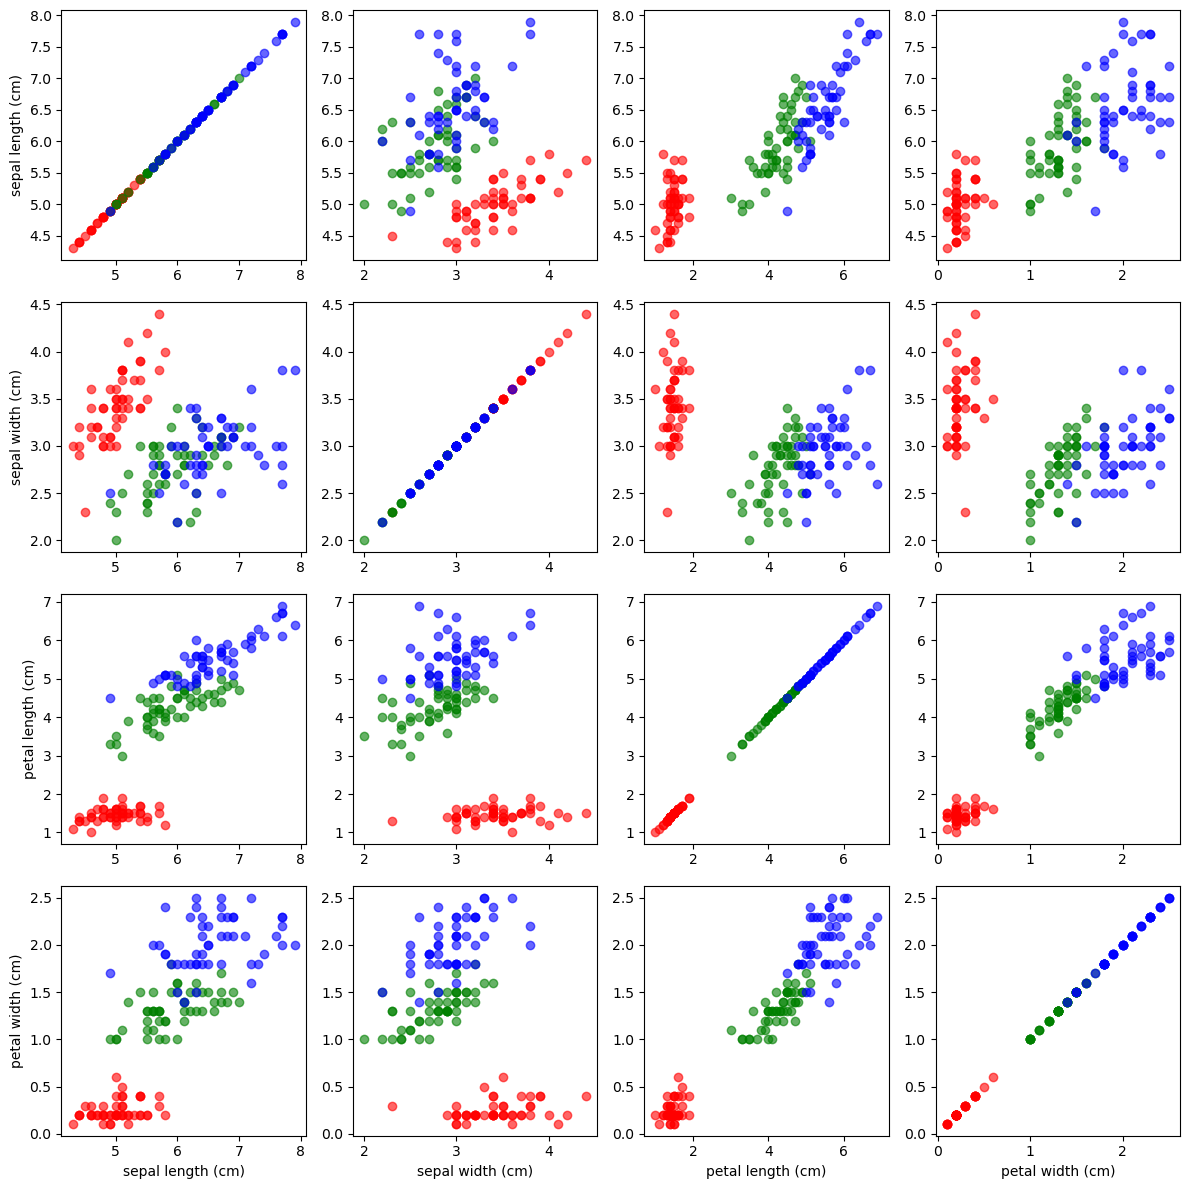

In [12]:
import matplotlib.pyplot as plt

colors = ['red', 'green', 'blue']

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i in range(4):
    for j in range(4):
        for species in range(3):
            axes[i, j].scatter(
                df.iloc[iris.target == species, j],
                df.iloc[iris.target == species, i],
                color=colors[species],
                alpha=0.6
            )
        
        # Подписываем оси
        if i == 3:
            axes[i, j].set_xlabel(df.columns[j])
        if j == 0:
            axes[i, j].set_ylabel(df.columns[i])

plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (112, 4)
X_test shape: (38, 4)
y_train shape: (112,)
y_test shape: (38,)


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy (k=3):", accuracy)

Test accuracy (k=3): 0.9736842105263158


In [10]:
for k in [1, 3, 5]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"k={k}, accuracy={acc}")

k=1, accuracy=0.9473684210526315
k=3, accuracy=0.9736842105263158
k=5, accuracy=0.9736842105263158


In [ ]:
 k=3 or k=5 gives the best accuracy because
k=1 may overfit, while moderate k values reduce noise.

In [11]:
new_sample = [[5.0, 2.9, 1.0, 0.2]]

prediction = knn.predict(new_sample)

print("Predicted class index:", prediction[0])
print("Predicted class name:", iris.target_names[prediction[0]])

Predicted class index: 0
Predicted class name: setosa
